In [6]:
import kagglehub
path = kagglehub.dataset_download("fedesoriano/heart-failure-prediction")

Using Colab cache for faster access to the 'heart-failure-prediction' dataset.


In [7]:
import os
print(os.listdir(path))

['heart.csv']


In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import warnings
warnings.filterwarnings('ignore')

The output shows a CSV file named `heart.csv`. Let's load it into a pandas DataFrame and display the first few rows.

In [9]:
import pandas as pd

df = pd.read_csv(os.path.join(path, 'heart.csv'))
display(df.head())

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [10]:
df.shape

(918, 12)

In [11]:
df.columns

Index(['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS',
       'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope',
       'HeartDisease'],
      dtype='object')

In [12]:
df.dtypes

,0
Age,int64
Sex,object
ChestPainType,object
RestingBP,int64
Cholesterol,int64
FastingBS,int64
RestingECG,object
MaxHR,int64
ExerciseAngina,object
Oldpeak,float64


In [13]:
df.isnull().sum() # dataset consists no null values

,0
Age,0
Sex,0
ChestPainType,0
RestingBP,0
Cholesterol,0
FastingBS,0
RestingECG,0
MaxHR,0
ExerciseAngina,0
Oldpeak,0


In [14]:
# Seprating Numerical and Categorical Features
num_features = [feature for feature in df.columns if df[feature].dtypes != 'O']
cat_features = [feature for feature in df.columns if df[feature].dtypes == 'O']
print("Numerical_Features:", num_features)
print("-"*100)
print("Categorical_Features:", cat_features)

Numerical_Features: ['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak', 'HeartDisease']
----------------------------------------------------------------------------------------------------
Categorical_Features: ['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope']


In [15]:
# no of unique values in each categorical column
for col in cat_features:
  print(f"{col}:{df[col].value_counts().count()}")
  print("-"*10)

Sex:2
----------
ChestPainType:4
----------
RestingECG:3
----------
ExerciseAngina:2
----------
ST_Slope:3
----------


In [16]:
for col in cat_features:
  print(f"{col}:{df[col].value_counts(normalize=True)*100}")
  print("-"*10)

Sex:Sex
M    78.976035
F    21.023965
Name: proportion, dtype: float64
----------
ChestPainType:ChestPainType
ASY    54.030501
NAP    22.113290
ATA    18.845316
TA      5.010893
Name: proportion, dtype: float64
----------
RestingECG:RestingECG
Normal    60.130719
LVH       20.479303
ST        19.389978
Name: proportion, dtype: float64
----------
ExerciseAngina:ExerciseAngina
N    59.586057
Y    40.413943
Name: proportion, dtype: float64
----------
ST_Slope:ST_Slope
Flat    50.108932
Up      43.028322
Down     6.862745
Name: proportion, dtype: float64
----------


In [17]:
num_features

['Age',
 'RestingBP',
 'Cholesterol',
 'FastingBS',
 'MaxHR',
 'Oldpeak',
 'HeartDisease']

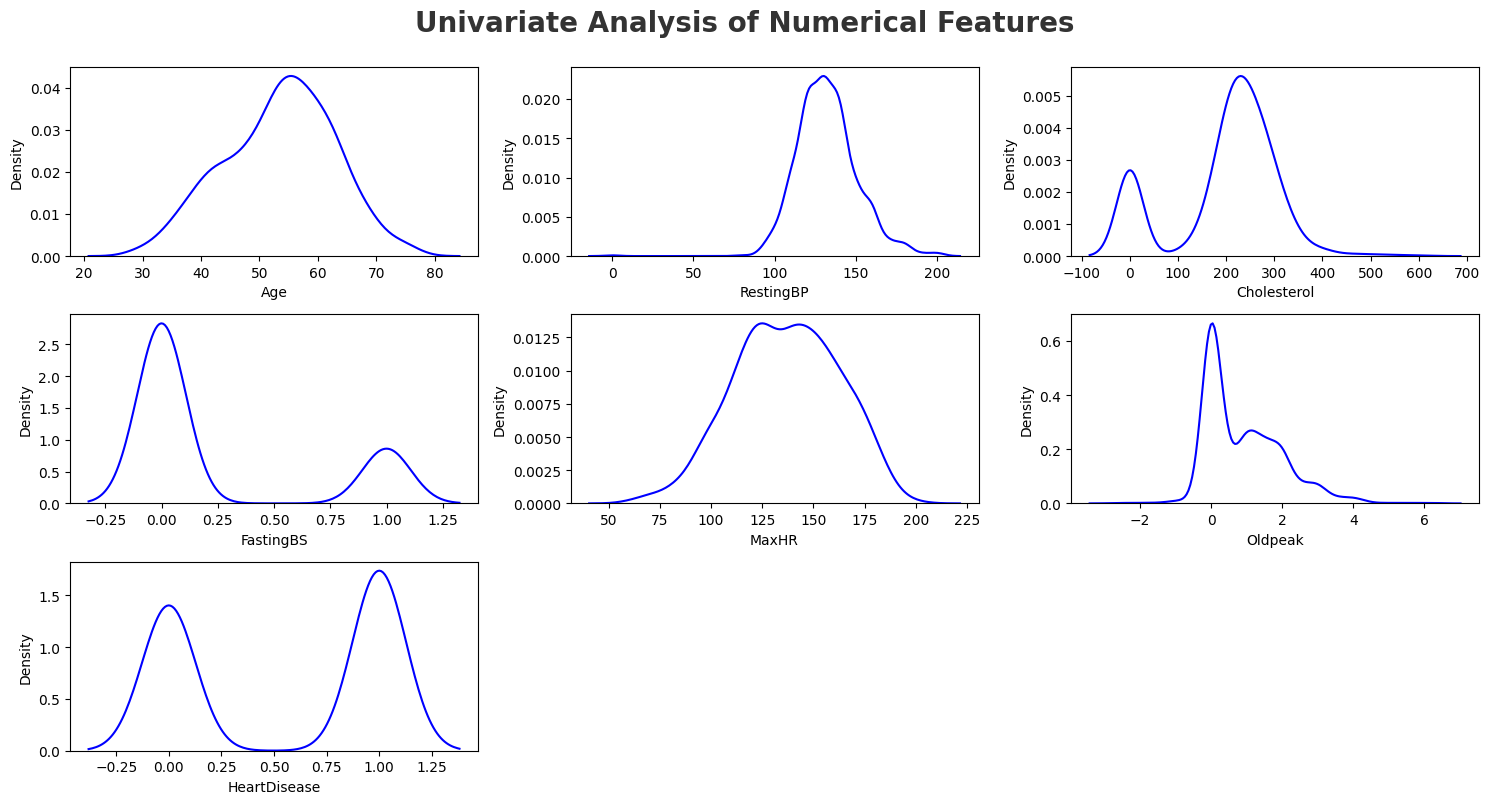

In [18]:
plt.figure(figsize=(15,8))
plt.suptitle('Univariate Analysis of Numerical Features', fontsize=20, fontweight='bold', alpha=0.8, y=1.)
for i in range(0,len(num_features)):
    plt.subplot(3,3,i+1)
    sns.kdeplot(x=df[num_features[i]], color='blue')
    plt.xlabel(num_features[i])
    plt.tight_layout()

Resting BP : Its graph is Left skewed means most of the values are large  few values are extremely small (outliers)

Old Peak : Its graph is right skewed means most of the values are small few values are large (outliers)

Cholestrol : Its graph is almost Non skewed or symmetric but consists few outliers

Age : Its graph is symmetric most lie in 30-80 but also few outliers

Fasting BS , HeartDisease , MaxHR : Their graph follow symmetric Distribution



In [19]:
cat_features.append('HeartDisease')
cat_features

['Sex',
 'ChestPainType',
 'RestingECG',
 'ExerciseAngina',
 'ST_Slope',
 'HeartDisease']

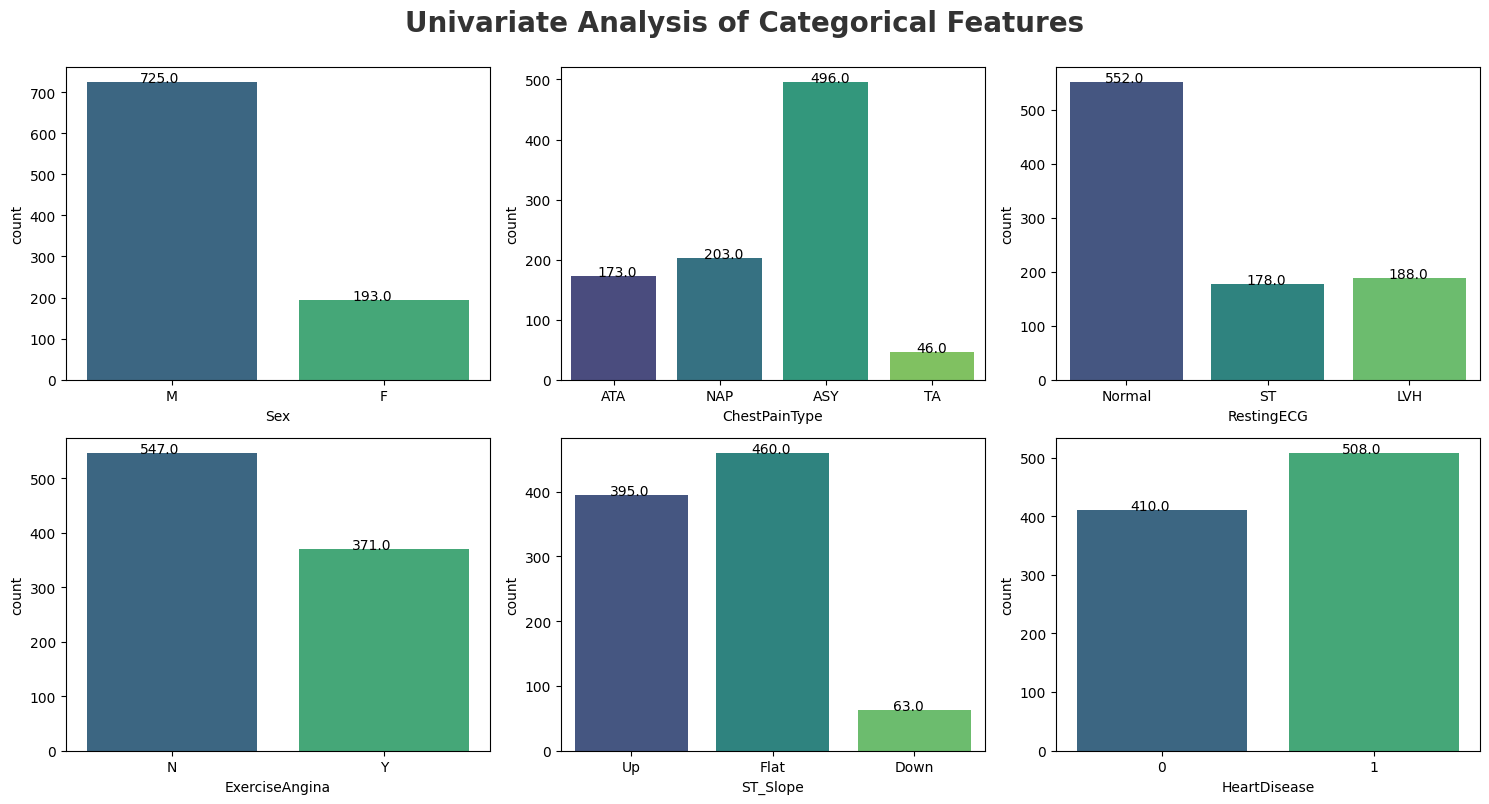

In [20]:
plt.figure(figsize=(15, 8))
plt.suptitle('Univariate Analysis of Categorical Features', fontsize=20, fontweight='bold', alpha=0.8, y=1.)

for i in range(0, len(cat_features)):
    plt.subplot(2, 3, i+1)
    ax = sns.countplot(x=df[cat_features[i]],palette="viridis")
    if df[cat_features[i]].value_counts().count() <10:
        for p in ax.patches:
            ax.annotate('{:.1f}'.format(p.get_height()), (p.get_x()+0.25, p.get_height()+0.01))
    else:
        for p in ax.patches:
            ax.annotate("{:.0f}".format(p.get_height()), (p.get_x()+0.1, p.get_height()+0.5))
            plt.xticks(rotation=90)
            fontsize=8
    plt.xlabel(cat_features[i])
    plt.tight_layout()

Sex : M > F

ChestPainType : ASY > NAP > ATA > TA

RestingECG : Normal > ST > LVH

ExerciseAngina : N > Y

ST_Slope : Flat > UP > Down

HeartDisease : Most of the peoples having Heart Disease

Multivariate Analysis And Feature Selection

In [21]:
num_features.remove("HeartDisease")
num_features

['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak']

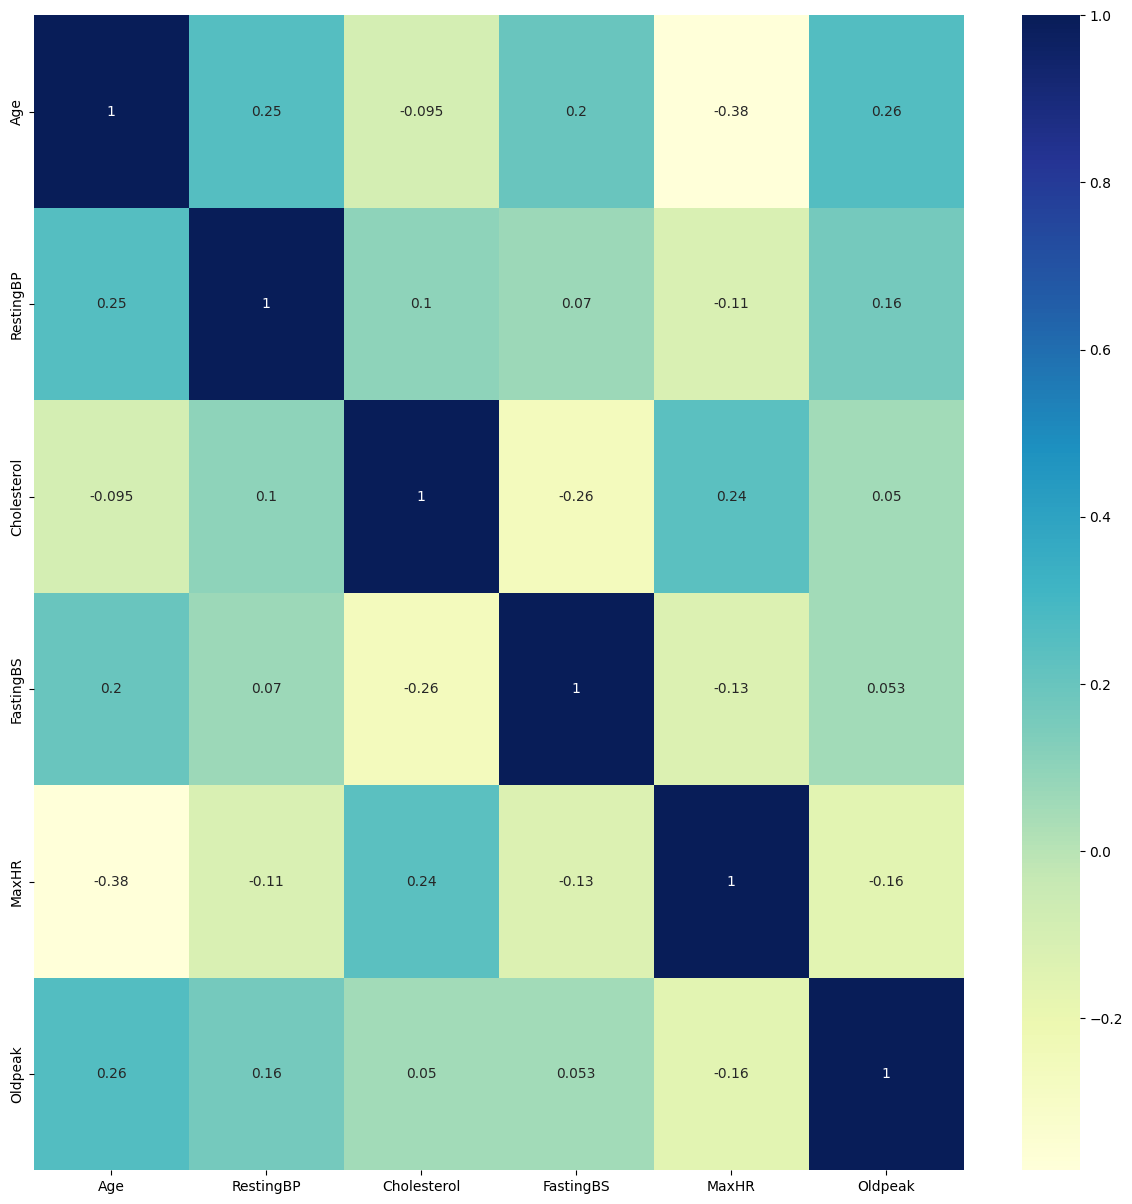

In [22]:
plt.figure(figsize = (15,15))
sns.heatmap(df[num_features].corr(), annot=True, cmap="YlGnBu")
plt.show()
# From the below heatmap it is clear that our Numerical_features do not consist Multicolinearty

In [23]:
num_features_new = num_features.copy()
num_features_new.append('HeartDisease')
num_features_new

['Age',
 'RestingBP',
 'Cholesterol',
 'FastingBS',
 'MaxHR',
 'Oldpeak',
 'HeartDisease']

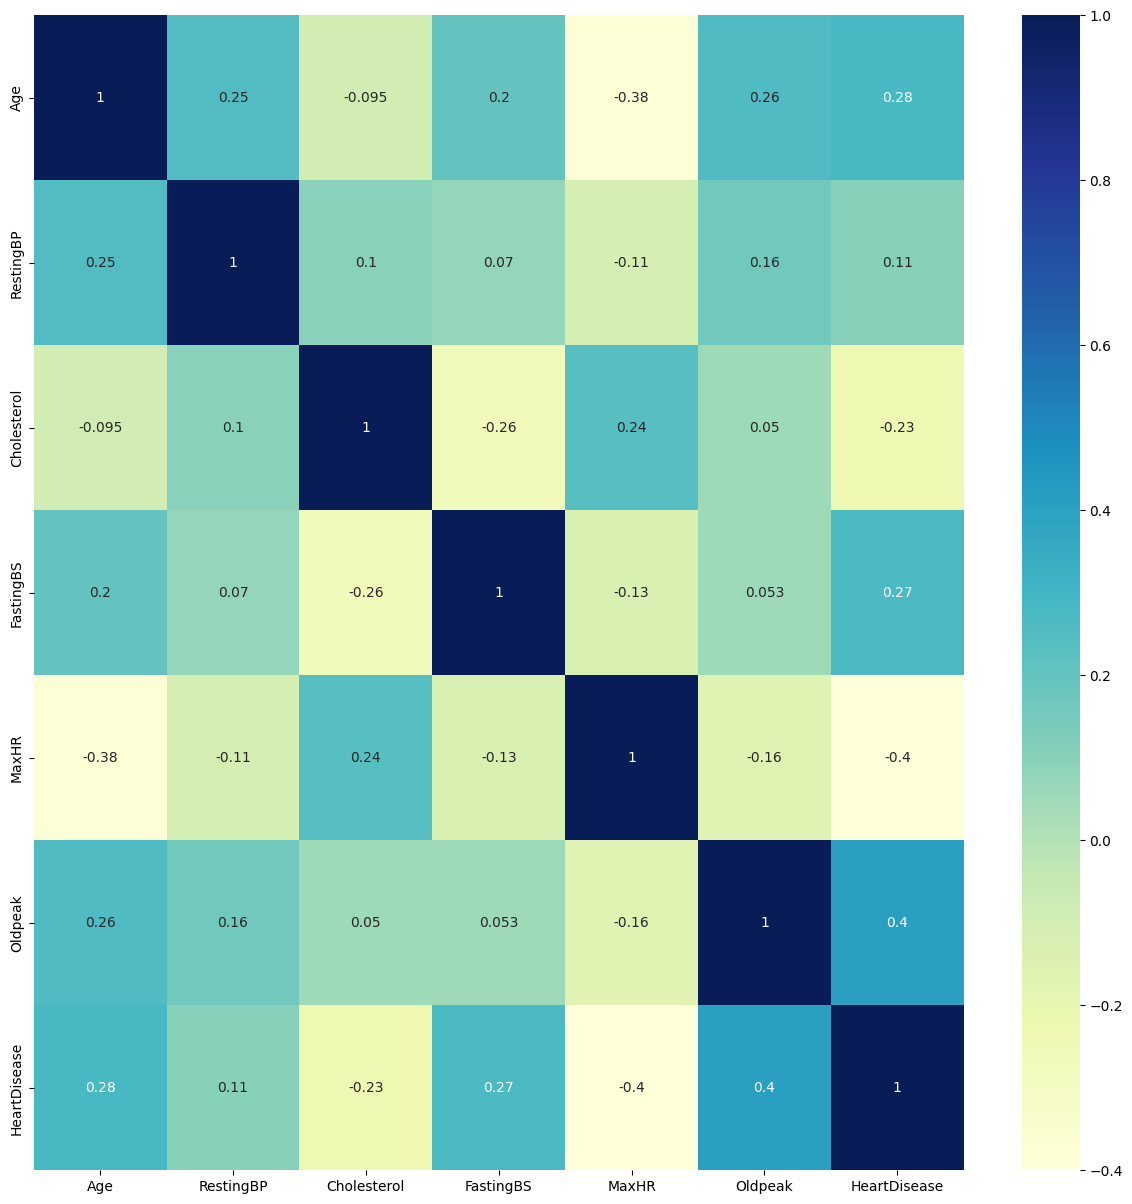

In [24]:
plt.figure(figsize = (15,15))
sns.heatmap(df[num_features_new].corr(), annot=True, cmap="YlGnBu")
plt.show()

HeartDisease is slightly dependent on Age , Cholesterol , FastingBS as compared to another numerical features

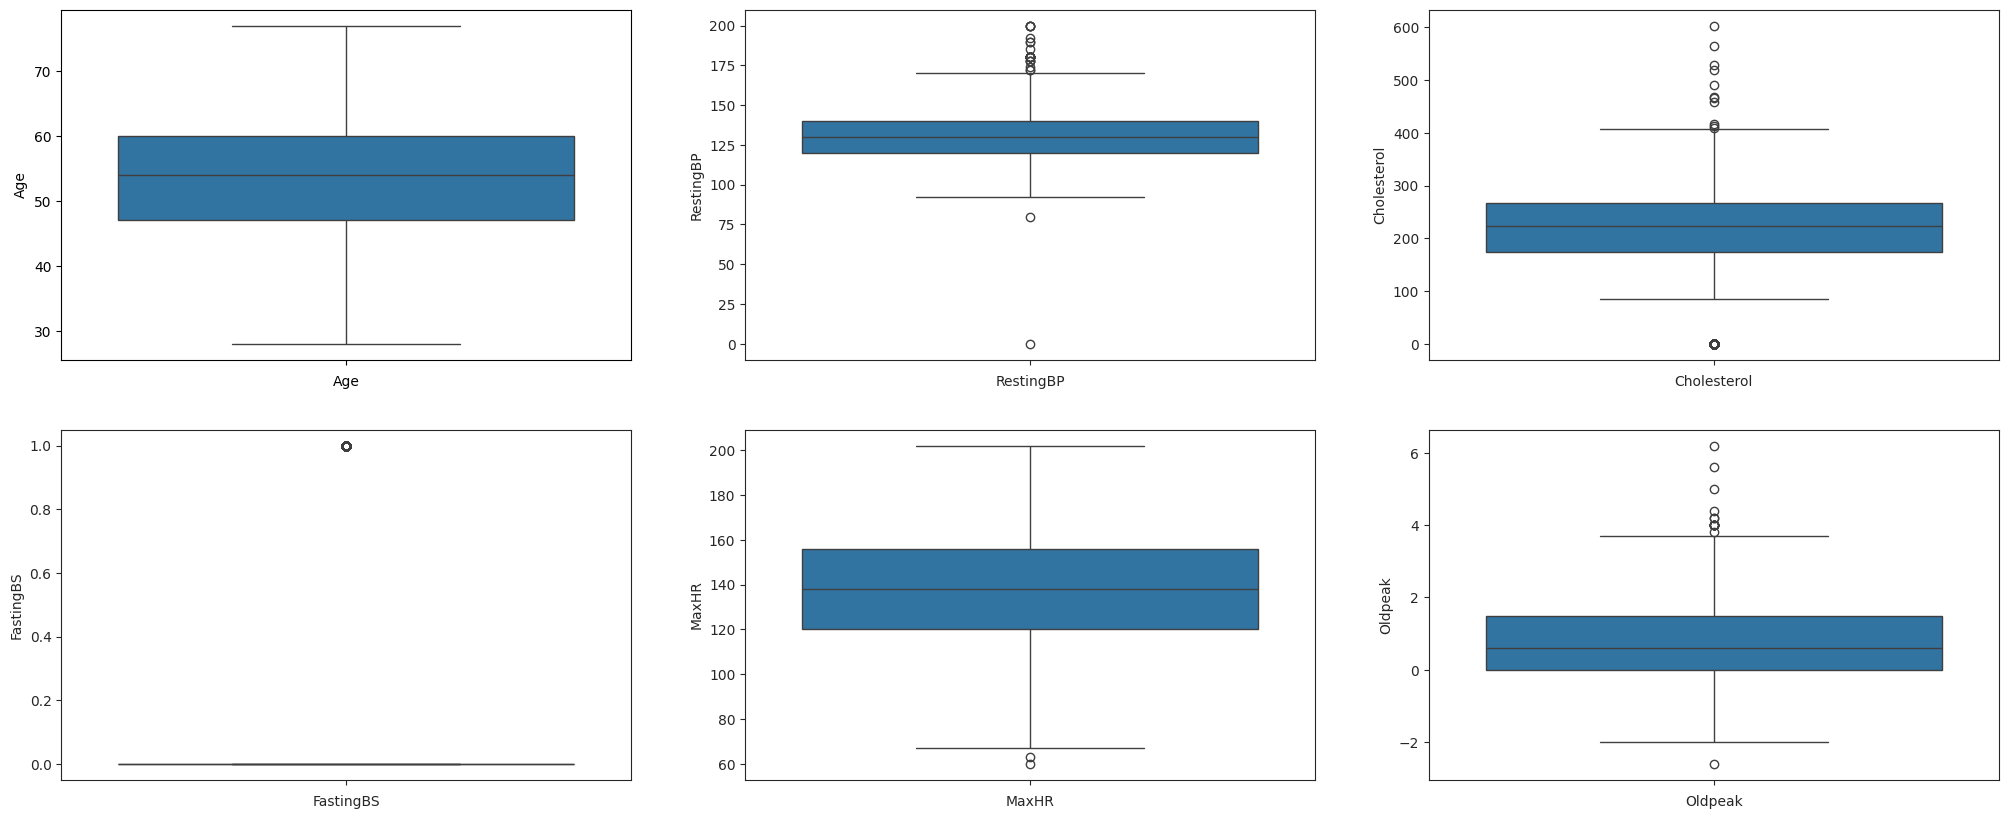

In [25]:
# Detecting Outliers
cont_features = num_features.copy()
plt.figure(figsize=(25, 10))

for i in range(len(cont_features)):
        plt.subplot(2,3,i+1)
        sns.set_style('ticks')
        plt.xlabel(cont_features[i])
        ax = sns.boxplot(df[cont_features[i]])

RestingBP , Cholestrol and OldPeak have outliers For these columns we have to do outlier Treatement

In [26]:
# Capping the Outliers
def detect_outliers(col):
    # Finding the IQR
    percentile25 = df[col].quantile(0.25)
    percentile75 = df[col].quantile(0.75)
    print('\n ####', col , '####')
    print("percentile25",percentile25)
    print("percentile75",percentile75)
    iqr = percentile75 - percentile25
    upper_limit = percentile75 + 1.5 * iqr
    lower_limit = percentile25 - 1.5 * iqr
    print("Upper limit",upper_limit)
    print("Lower limit",lower_limit)
    df.loc[(df[col]>upper_limit), col]= upper_limit
    df.loc[(df[col]<lower_limit), col]= lower_limit
    return df

In [27]:
Out_col = ['RestingBP','Cholesterol','Oldpeak',"MaxHR"]
for col in Out_col:
         detect_outliers(col)


 #### RestingBP ####
percentile25 120.0
percentile75 140.0
Upper limit 170.0
Lower limit 90.0

 #### Cholesterol ####
percentile25 173.25
percentile75 267.0
Upper limit 407.625
Lower limit 32.625

 #### Oldpeak ####
percentile25 0.0
percentile75 1.5
Upper limit 3.75
Lower limit -2.25

 #### MaxHR ####
percentile25 120.0
percentile75 156.0
Upper limit 210.0
Lower limit 66.0


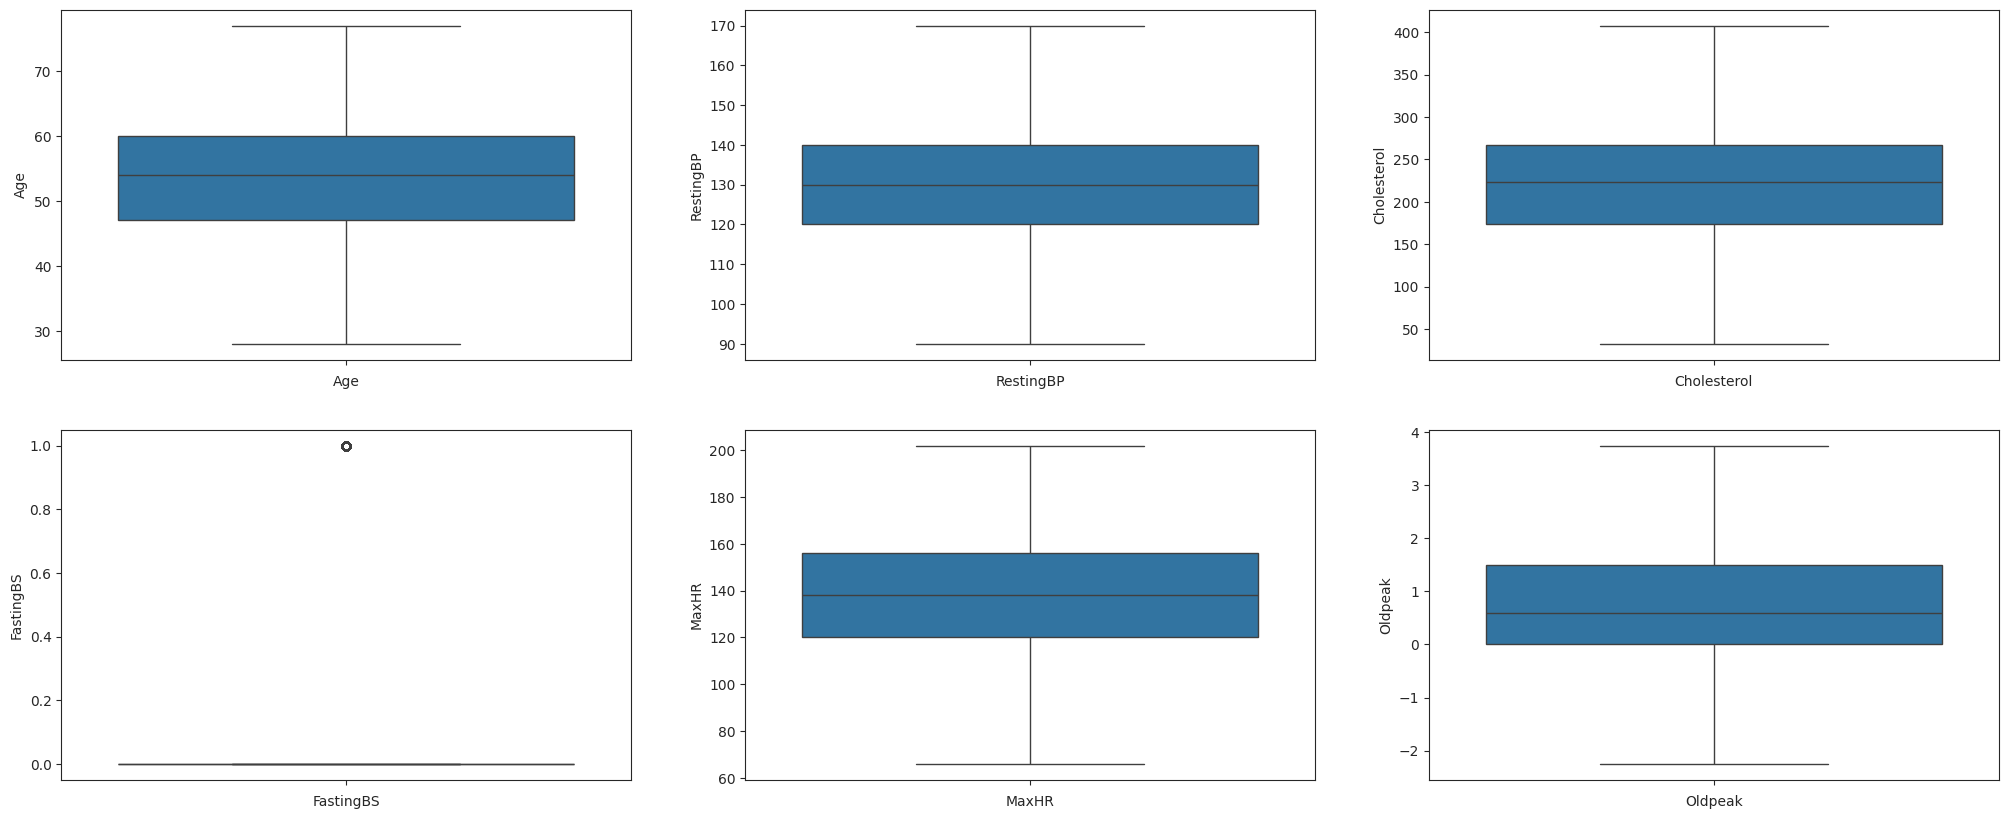

In [28]:
cont_features = num_features.copy()
plt.figure(figsize=(25, 10))

for i in range(len(cont_features)):
        plt.subplot(2,3,i+1)
        sns.set_style('ticks')
        plt.xlabel(cont_features[i])
        ax = sns.boxplot(df[cont_features[i]])

In [29]:
Categorical_Features = ['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope']
for col in Categorical_Features:
  print(f"{col} : {df[col].unique()}")
  print("-"*10)


Sex : ['M' 'F']
----------
ChestPainType : ['ATA' 'NAP' 'ASY' 'TA']
----------
RestingECG : ['Normal' 'ST' 'LVH']
----------
ExerciseAngina : ['N' 'Y']
----------
ST_Slope : ['Up' 'Flat' 'Down']
----------


Data Encoding

In [30]:
df["Sex"]  = df["Sex"].map({"M":0, "F":1})

df["ChestPainType"]  = df["ChestPainType"].map({"ASY":0, "ATA":1, "NAP":2, "TA":3})

df["RestingECG"]  = df["RestingECG"].map({"Normal":0, "ST":1, "LVH":2})

df["ExerciseAngina"]  = df["ExerciseAngina"].map({"N":0, "Y":1})

df["ST_Slope"]  = df["ST_Slope"].map({"Flat":0, "Up":1, "Down":2})

print("Mapped Succesfully")


Mapped Succesfully


Detecting Mullticollinearty and Treating Them

In [31]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif=pd.DataFrame()
vif["features"]=df.columns
vif["VIF"]=[variance_inflation_factor(df.values,i) for i in range(len(df.columns))]
vif

,features,VIF
0,Age,33.799751
1,Sex,1.446503
2,ChestPainType,2.112576
3,RestingBP,50.634047
4,Cholesterol,6.840696
5,FastingBS,1.513199
6,RestingECG,1.662640
7,MaxHR,25.073939
8,ExerciseAngina,2.643405
9,Oldpeak,2.333115


In [32]:
# Resting BP , Age , MaxHR

In [33]:
df.drop("RestingBP",axis=1,inplace=True)

In [34]:
df.columns

Index(['Age', 'Sex', 'ChestPainType', 'Cholesterol', 'FastingBS', 'RestingECG',
       'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope', 'HeartDisease'],
      dtype='object')

In [35]:
vif=pd.DataFrame()
vif["features"]=df.columns
vif["VIF"]=[variance_inflation_factor(df.values,i) for i in range(len(df.columns))]
vif

,features,VIF
0,Age,19.268314
1,Sex,1.446313
2,ChestPainType,2.108978
3,Cholesterol,6.619399
4,FastingBS,1.512045
5,RestingECG,1.652836
6,MaxHR,18.226575
7,ExerciseAngina,2.591831
8,Oldpeak,2.332222
9,ST_Slope,2.278660


In [36]:
df.drop("Age",axis=1,inplace=True)

In [37]:
vif=pd.DataFrame()
vif["features"]=df.columns
vif["VIF"]=[variance_inflation_factor(df.values,i) for i in range(len(df.columns))]
vif

,features,VIF
0,Sex,1.436682
1,ChestPainType,2.068102
2,Cholesterol,6.461220
3,FastingBS,1.467881
4,RestingECG,1.622915
5,MaxHR,11.748655
6,ExerciseAngina,2.489594
7,Oldpeak,2.320892
8,ST_Slope,2.229657
9,HeartDisease,3.918766


In [38]:
df.drop("MaxHR",axis=1,inplace=True)

In [39]:
vif=pd.DataFrame()
vif["features"]=df.columns
vif["VIF"]=[variance_inflation_factor(df.values,i) for i in range(len(df.columns))]
vif

,features,VIF
0,Sex,1.395010
1,ChestPainType,1.727583
2,Cholesterol,3.721777
3,FastingBS,1.438868
4,RestingECG,1.616126
5,ExerciseAngina,2.488151
6,Oldpeak,2.317045
7,ST_Slope,1.756248
8,HeartDisease,3.250766


In [40]:
df.head(10)

,Sex,ChestPainType,Cholesterol,FastingBS,RestingECG,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,0,1,289.0,0,0,0,0.0,1,0
1,1,2,180.0,0,0,0,1.0,0,1
2,0,1,283.0,0,1,0,0.0,1,0
3,1,0,214.0,0,0,1,1.5,0,1
4,0,2,195.0,0,0,0,0.0,1,0
5,0,2,339.0,0,0,0,0.0,1,0
6,1,1,237.0,0,0,0,0.0,1,0
7,0,1,208.0,0,0,0,0.0,1,0
8,0,0,207.0,0,0,1,1.5,0,1
9,1,1,284.0,0,0,0,0.0,1,0


In [41]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

X_train , X_test , y_train , y_test = train_test_split(df.drop("HeartDisease",axis=1),df["HeartDisease"],test_size=0.2,random_state=42)



In [42]:
models={"DT":DecisionTreeClassifier(),
        "SVC":SVC(),
        "Log_Reg":LogisticRegression()}


def model_train_eval(X_train , X_test , y_train , y_test , models):
    evaluation = {}
    for i in range(len(models)):
        model = list(models.values())[i]
        model.fit(X_train , y_train)
        y_pred = model.predict(X_test)
        model_score = accuracy_score(y_test , y_pred)
        evaluation[list(models.keys())[i]] = model_score
    return evaluation

In [43]:
model_train_eval(X_train , X_test , y_train , y_test , models)

{'DT': 0.782608695652174,
 'SVC': 0.5815217391304348,
 'Log_Reg': 0.8369565217391305}

With LogisticRegression Model Accuracy is highest

In [44]:
# Hyperparameter tuning
from sklearn.model_selection import GridSearchCV
model = LogisticRegression()
params = {"penalty":["l1","l2","elasticnet"],"C":[1,2,12,8,30]}
clf = GridSearchCV(estimator=model,param_grid=params,cv=5,scoring="accuracy",verbose=2)
clf.fit(X_train,y_train)

Fitting 5 folds for each of 15 candidates, totalling 75 fits
[CV] END ....................................C=1, penalty=l1; total time=   0.0s
[CV] END ....................................C=1, penalty=l1; total time=   0.0s
[CV] END ....................................C=1, penalty=l1; total time=   0.0s
[CV] END ....................................C=1, penalty=l1; total time=   0.0s
[CV] END ....................................C=1, penalty=l1; total time=   0.0s
[CV] END ....................................C=1, penalty=l2; total time=   0.0s
[CV] END ....................................C=1, penalty=l2; total time=   0.0s
[CV] END ....................................C=1, penalty=l2; total time=   0.0s
[CV] END ....................................C=1, penalty=l2; total time=   0.0s
[CV] END ....................................C=1, penalty=l2; total time=   0.0s
[CV] END ............................C=1, penalty=elasticnet; total time=   0.0s
[CV] END ............................C=1, penalt

GridSearchCV(cv=5, estimator=LogisticRegression(),
             param_grid={'C': [1, 2, 12, 8, 30],
                         'penalty': ['l1', 'l2', 'elasticnet']},
             scoring='accuracy', verbose=2)

In [45]:
clf.best_params_

{'C': 1, 'penalty': 'l2'}

In [46]:
clf.best_score_

np.float64(0.8474047153107819)

In [47]:
y_pred = clf.best_estimator_.predict(X_test)
accuracy_score(y_test,y_pred)

0.8369565217391305

In [48]:
final_model = LogisticRegression(C=1, penalty='l2')
final_model.fit(X_train,y_train)

LogisticRegression(C=1)

In [49]:
final_model.predict(X_test)

array([0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 0, 0, 1,
       0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 0,
       0, 1, 0, 1, 1, 0, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 1,
       1, 1, 1, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 0, 1,
       0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 1, 1, 0,
       1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1,
       1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0,
       1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 0, 1,
       1, 1, 0, 0, 1, 1, 0, 1])